# Profiling skforecast

This document shows the profiling of the main classes, methods and functions available in skforecast. Understanding the bottlenecks will help to:

+ Use it more efficiently
+ Improve the code for future releases

## Libraries and data

In [ ]:
# Libraries
# ==============================================================================
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import platform
import psutil

import sklearn
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor

import skforecast
from skforecast.recursive import ForecasterRecursive

%load_ext pyinstrument

In [2]:
# Versions
# ==============================================================================
print(f"Python version      : {platform.python_version()}")
print(f"scikit-learn version: {sklearn.__version__}")
print(f"skforecast version  : {skforecast.__version__}")
print(f"pandas version      : {pd.__version__}")
print(f"numpy version       : {np.__version__}")
print(f"psutil version      : {psutil.__version__}")
print("")

# System information
# ==============================================================================
print(f"Machine type: {platform.machine()}")
print(f"Processor type: {platform.processor()}")
print(f"Platform type: {platform.platform()}")
print(f"Operating system: {platform.system()}")
print(f"Operating system release: {platform.release()}")
print(f"Operating system version: {platform.version()}")
print(f"Number of physical cores: {psutil.cpu_count(logical=False)}")
print(f"Number of logical cores: {psutil.cpu_count(logical=True)}")

Python version      : 3.14.3
scikit-learn version: 1.9.1
skforecast version  : 0.26.0
pandas version      : 2.3.3
numpy version       : 2.5.3
psutil version      : 7.2.2

Machine type: arm64
Processor type: arm
Platform type: macOS-27.0.1-arm64-arm-64bit-Mach-O
Operating system: Darwin
Operating system release: 27.0.0
Operating system version: Darwin Kernel Version 27.0.0: Tue Aug 11 21:02:59 PDT 2026; root:xnu-13432.1.9~1/RELEASE_ARM64_T8142
Number of physical cores: 10
Number of logical cores: 10


A time series of length 1000 with random values is created.

In [3]:
# Data
# ==============================================================================
np.random.seed(123)
n = 1_000
data = pd.Series(data = np.random.normal(size=n))

## Profiling fit

To isolate the training process of the estimator from the other parts of the code, a dummy estimator class is used.

╭─────────────────────────────── IgnoredArgumentWarning ───────────────────────────────╮
│ The number of bins has been reduced from 10 to 1 due to duplicated edges. This       │
│ happens when the values used to compute the edges of the bins are highly             │
│ concentrated or contain many repeated values.                                        │
│                                                                                      │
│ Category : skforecast.exceptions.IgnoredArgumentWarning                              │
│ Location :                                                                           │
│ /opt/homebrew/Caskroom/miniconda/base/envs/skforecast_py14/lib/python3.14/site-packa │
│ ges/skforecast/preprocessing/_preprocessing.py:2455                                  │
│ Suppress : warnings.simplefilter('ignore', category=IgnoredArgumentWarning)          │
╰──────────────────────────────────────────────────────────────────────────────────────╯

_     ._   __/__   _ _  _  _ _/_   Recorded: 20:41:55  Samples:  29
 /_//_/// /_\ / //_// / //_'/ //     Duration: 0.031     CPU time: 0.023
/   _/                      v5.1.3

Cell [5]

0.030 <module>  /var/folders/wt/8tvn563d5v55nspfbydgqb9r0000gp/T/ipykernel_82424/1388718273.py:1
└─ 0.030 wrapper  skforecast/utils/utils.py:2877
      [80 frames hidden]  skforecast, sklearn, narwhals, import...
         0.009 PosixPath.open  pathlib/__init__.py:763
         └─ 0.007 [self]  pathlib/__init__.py
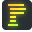

In [4]:
%%pyinstrument

forecaster = ForecasterRecursive(
                 estimator = DummyRegressor(strategy='constant', constant=1.),
                 lags      = 24
             )

forecaster.fit(y=data)

Almost all of the time spent by `fit` is required by the `create_train_X_y` method.

_     ._   __/__   _ _  _  _ _/_   Recorded: 20:41:55  Samples:  153
 /_//_/// /_\ / //_// / //_'/ //     Duration: 0.229     CPU time: 0.483
/   _/                      v5.1.3

Cell [6]

0.229 <module>  /var/folders/wt/8tvn563d5v55nspfbydgqb9r0000gp/T/ipykernel_82424/4842675.py:1
└─ 0.229 wrapper  skforecast/utils/utils.py:2877
      [54 frames hidden]  skforecast, sklearn, joblib, multipro...
         0.142 TreeGrower.split_next  sklearn/ensemble/_hist_gradient_boosting/grower.py:486
         └─ 0.128 [self]  sklearn/ensemble/_hist_gradient_boosting/grower.py
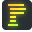

In [5]:
%%pyinstrument

forecaster = ForecasterRecursive(
                 estimator = HistGradientBoostingRegressor(max_iter=10, random_state=123),
                 lags      = 24
             )

forecaster.fit(y=data)

When training a forecaster with a real machine learning estimator, the time spent by `create_train_X_y` is negligible compared to the time needed by the `fit` method of the estimator. Therefore, improving the speed of `create_train_X_y` will not have much impact.

## Profiling create_train_X_y

Understand how the `create_train_X_y` method is influenced by the length of the series and the number of lags. 

In [6]:
# Profiling `create_train_X_y` for different length of series and number of lags
# ======================================================================================
series_length = np.linspace(1000, 1000000, num=5, dtype=int)
n_lags = [5, 10, 50, 100, 200]
results = {}

for lags in n_lags:
    execution_time = []
    forecaster = ForecasterRecursive(
                     estimator = DummyRegressor(strategy='constant', constant=1.),
                     lags      = lags
                 )

    for n in series_length:
        y = pd.Series(data = np.random.normal(size=n))
        tic = time.perf_counter()
        _ = forecaster.create_train_X_y(y=y)
        toc = time.perf_counter()
        execution_time.append(toc - tic)

    results[lags] = execution_time

results = pd.DataFrame(
              data = results,
              index = series_length
          )

results

,5,10,50,100,200
1000,0.000319,0.000223,0.000289,0.000245,0.000267
250750,0.001374,0.001413,0.006199,0.009560,0.021286
500500,0.001723,0.002631,0.012455,0.024050,0.047958
750250,0.002937,0.003883,0.017470,0.035970,0.071971
1000000,0.003751,0.006750,0.023587,0.043057,0.096112


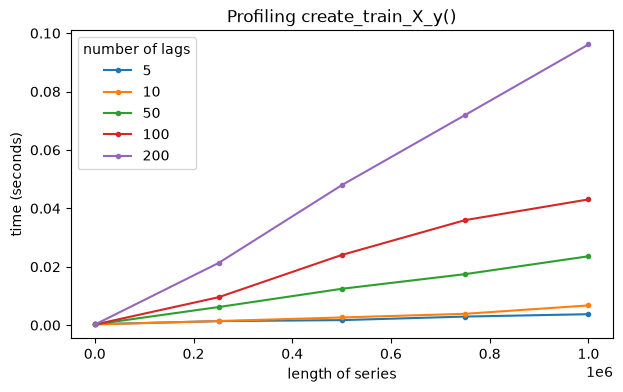

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
results.plot(ax=ax, marker='.')
ax.set_xlabel('length of series')
ax.set_ylabel('time (seconds)')
ax.set_title('Profiling create_train_X_y()')
ax.legend(title='number of lags');

## Profiling predict

In [8]:
forecaster = ForecasterRecursive(
                 estimator = DummyRegressor(strategy='constant', constant=1.),
                 lags      = 24
             )

forecaster.fit(y=data)

╭─────────────────────────────── IgnoredArgumentWarning ───────────────────────────────╮
│ The number of bins has been reduced from 10 to 1 due to duplicated edges. This       │
│ happens when the values used to compute the edges of the bins are highly             │
│ concentrated or contain many repeated values.                                        │
│                                                                                      │
│ Category : skforecast.exceptions.IgnoredArgumentWarning                              │
│ Location :                                                                           │
│ /opt/homebrew/Caskroom/miniconda/base/envs/skforecast_py14/lib/python3.14/site-packa │
│ ges/skforecast/preprocessing/_preprocessing.py:2455                                  │
│ Suppress : warnings.simplefilter('ignore', category=IgnoredArgumentWarning)          │
╰──────────────────────────────────────────────────────────────────────────────────────╯

_     ._   __/__   _ _  _  _ _/_   Recorded: 20:41:56  Samples:  8
 /_//_/// /_\ / //_// / //_'/ //     Duration: 0.008     CPU time: 0.008
/   _/                      v5.1.3

Cell [10]

0.008 <module>  /var/folders/wt/8tvn563d5v55nspfbydgqb9r0000gp/T/ipykernel_82424/3639615597.py:1
└─ 0.008 wrapper  skforecast/utils/utils.py:2877
      [12 frames hidden]  skforecast, sklearn, numpy, <built-in...
         0.008 ForecasterRecursive._recursive_predict  skforecast/recursive/_forecaster_recursive.py:1651
         │  0.002 ndarray.ravel  <built-in>
         └─ 0.002 [self]  skforecast/recursive/_forecaster_recursive.py
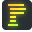

In [9]:
%%pyinstrument

_ = forecaster.predict(steps=1000)

In [10]:
forecaster = ForecasterRecursive(
                 estimator = HistGradientBoostingRegressor(max_iter=10, random_state=123),
                 lags      = 24
             )

forecaster.fit(y=data)

_     ._   __/__   _ _  _  _ _/_   Recorded: 20:41:56  Samples:  1031
 /_//_/// /_\ / //_// / //_'/ //     Duration: 1.077     CPU time: 2.582
/   _/                      v5.1.3

Cell [12]

1.077 <module>  /var/folders/wt/8tvn563d5v55nspfbydgqb9r0000gp/T/ipykernel_82424/3639615597.py:1
└─ 1.077 wrapper  skforecast/utils/utils.py:2877
      [15 frames hidden]  skforecast, sklearn, narwhals
         0.950 TreePredictor.predict  sklearn/ensemble/_hist_gradient_boosting/predictor.py:49
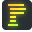

In [11]:
%%pyinstrument

_ = forecaster.predict(steps=1000)

Inside the `predict` method, the `append` action is the most expensive but, similar to what happen with `fit`, it is negligible compared to the time need by the `predict` method of the estimator.